# Estimating the Essential Matrix via the DLT

Your name: James Bishop

Your ID number: 9117504

No we're going to read two images in, a left image and a right image. And we are going to estimate the essential matrix between the two images.

In the last e-tivity, you estimated the homography that let us transform the images, at least approximately, so that we could line them up in a panorama. But it was a 2D estimation that works for planar scenes. The essential matrix, in a way, allows us to extend this concept beyond the need for a 2D scene, we can accept a 3D scene.

## Read the images, calibration, and do the feature extraction

Let's start by reading the two images.

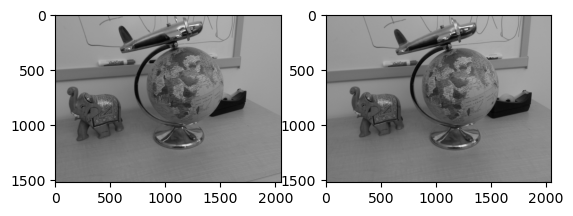

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imgL_color = cv2.imread('globe1.jpg')
imgR_color = cv2.imread('globe2.jpg')

imgL_color = cv2.cvtColor(imgL_color, cv2.COLOR_BGR2RGB)
imgR_color = cv2.cvtColor(imgR_color, cv2.COLOR_BGR2RGB)

imgL = cv2.imread('globe1.jpg',cv2.IMREAD_GRAYSCALE)
imgR = cv2.imread('globe2.jpg',cv2.IMREAD_GRAYSCALE)

f, axarr = plt.subplots(1,2)
axarr[0].imshow(imgL,cmap='gray')
axarr[1].imshow(imgR,cmap='gray');

We need the calibration to generate the essential matrix. We looked before at how to calibrate a camera, so we won't go through that again. Here, we just use the calibration.

In [22]:
# The calibration is the same for both images, as they were captured using the same camera.

# First two are radial distortion, second two are tangential, which we ignore (set to zero)
dist = np.array([0.138220594989358, -0.291158084324502, 0, 0])

# The projection matrix. 
K_init = np.array([[1901.61685419446, 0               , 1051.33708372959],
                   [0               , 1894.94457228005, 778.616424720309],
                   [0               , 0               , 1               ]])

h, w = imgL.shape[:2]


It's not obvious form the images above, but there is a slight radial distortion. We want to work with undistorted images (it makes our life a little easier). So, here, we undistort before the feature extraction.

(2048, 1520)
(16, 13, 2020, 1496)


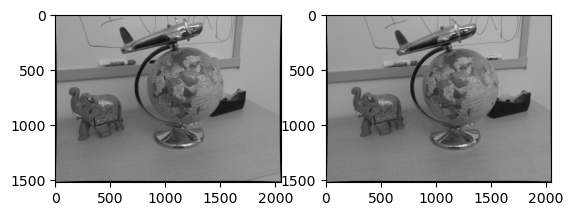

In [23]:
# We're going to use OpenCV to do this.
# When you undistort, we change the camera matrix slightly. OpenCV provides a hady function that updates this.
K_new, roi = cv2.getOptimalNewCameraMatrix(K_init, dist, (w,h), 1, (w,h))

# Now we will undistort the image pair
imgL = cv2.undistort(imgL, K_init, dist, None, K_new)
imgR = cv2.undistort(imgR, K_init, dist, None, K_new)

# we will just store the new camera matrix
K = K_new

# plot
f, axarr = plt.subplots(1,2)
axarr[0].imshow(imgL,cmap='gray')
axarr[1].imshow(imgR,cmap='gray');

print((w,h))
print(roi)

In [4]:
print(K)

[[1.90587264e+03 0.00000000e+00 1.05365048e+03]
 [0.00000000e+00 1.89726826e+03 7.79541999e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


You can see that the undistortion above is very slight. There is a slight curvature outward of the image. It is slight, but it does exist, so it is good to remove it. Let's now get rid of the black areas.

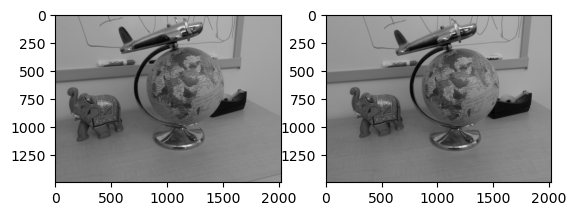

In [24]:
# crop the image. 
# Usefully, getOptimalNewCameraMatrix returns an roi that defines the area of the image without the black bits.
# Crop using np.array slicing
x, y, w, h = roi
imgL = imgL[y:y+h, x:x+w]
imgR = imgR[y:y+h, x:x+w]

# plot
f, axarr = plt.subplots(1,2)
axarr[0].imshow(imgL,cmap='gray')
axarr[1].imshow(imgR,cmap='gray');

In previous vision modules, you will have covered feature matching. I don't expect you to repeat that here. So I will give you the code to match the two images using ORB. And we will match the features between the frames.

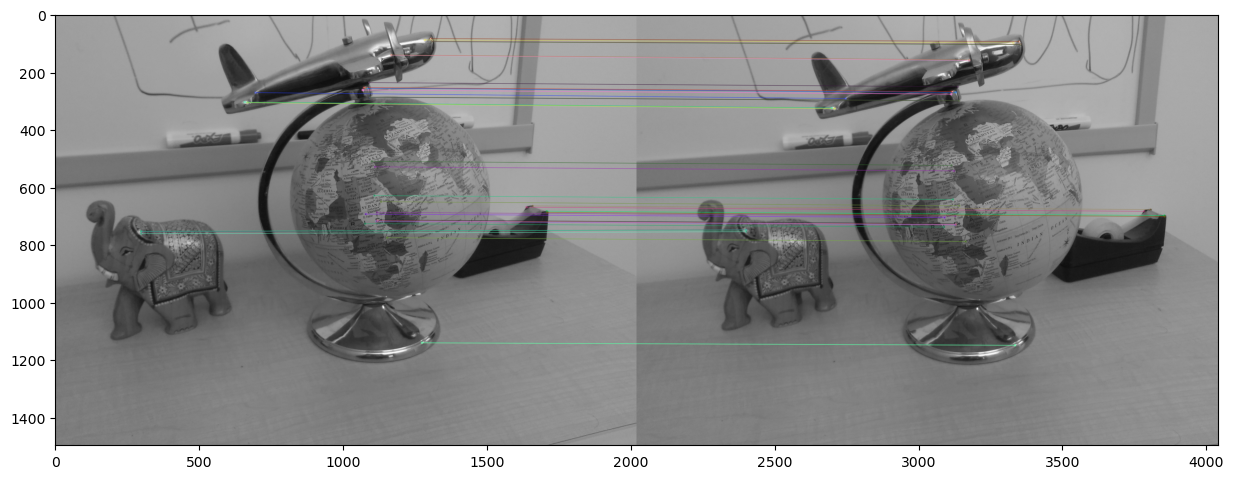

In [25]:
# Initiate ORB detector
orb = cv2.ORB_create()

# find the keypoints and descriptors with ORB
kp1, des1 = orb.detectAndCompute(imgL,None)
kp2, des2 = orb.detectAndCompute(imgR,None)
# create BFMatcher object
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
# Match descriptors.
matches = bf.match(des1,des2)
# Sort them in the order of their distance.
matches = sorted(matches, key = lambda x:x.distance)

N_PTS = 40

img3 = cv2.drawMatches(imgL,kp1,imgR,kp2,matches[:N_PTS],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize = (15,15)),plt.imshow(img3),plt.show();

left_pts = np.float32([kp1[m.queryIdx].pt for m in matches[:N_PTS]]).reshape(-1,2)
rght_pts = np.float32([kp2[m.trainIdx].pt for m in matches[:N_PTS]]).reshape(-1,2)

## Estimate the Essential Matrix

Now, let's get into your code.

We're going to estimate the essential matrix by using the DLT (again!). This is called the 8-point algorithm (as it requires a minimum of 8 points.

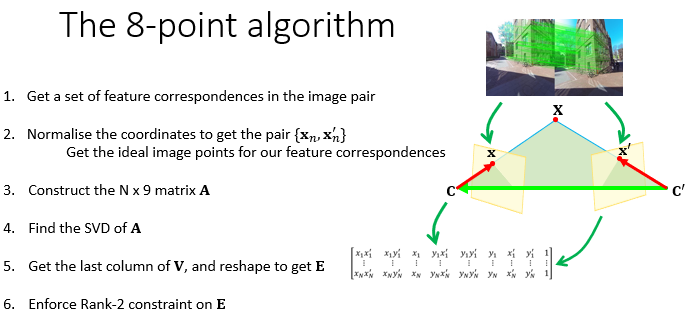

Step 1, we already have.

<font color='blue'>
    
#### Task
    
Complete the rest of the 8-point algorithm, steps 2 to 5. Refer to lecture 5.14 for the details on estimating the essential matrix.

<font color='blue'>

##### Step 2: normalise the image points 
The essential matrix assumes normalised image coordinate (though, the 8-point algorithm works on non-normalised image coordinates, but returns the fundamental matrix). Take a look at Lecture 4.12 for how to get the normalise image coordinates.
    
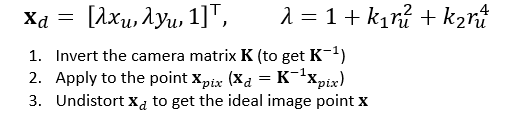
    
Note, however, you can skip the last undistortion step. We have already undistorted out image above, so we don't need to do that step here. (just do steps 1 and 2).
    
Remember, the result should be a set of homogeneous coordinates (so append with a 1)

## Homogenise and normalise features

In [27]:
############################
# Your code here

# Calculate K inverse
K_inv = np.linalg.inv(K)
print(K_inv)

#Convert left points and right points to homogenous co-ordinates
left_pts_hom = np.append(left_pts, np.ones((left_pts.shape[0], 1)), axis=1)
rght_pts_hom = np.append(rght_pts, np.ones((rght_pts.shape[0], 1)), axis=1)

#Initialise lists for left_pts_dist and rght_pts_dist
left_pts_dist = np.zeros((left_pts_hom.shape[0], 3))
rght_pts_dist = np.zeros((rght_pts_hom.shape[0], 3))

#Apply normalisation
for i in range(left_pts_hom.shape[0]):
    left_pts_dist[i] = np.dot(K_inv, left_pts_hom[i])
    rght_pts_dist[i] = np.dot(K_inv, rght_pts_hom[i])


print(left_pts_dist.shape)
print(rght_pts_dist.shape)

[[ 5.24694032e-04  0.00000000e+00 -5.52844117e-01]
 [ 0.00000000e+00  5.27073593e-04 -4.10876002e-01]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
(40, 3)
(40, 3)


<font color='blue'>

##### Steps 3 to 5:
    
At the end of these steps, print the essential matrix rank (Google to find the numpy function to use). At this point, the rank should b 3.

## Create A matrix

In [ ]:
############################
# Your code here

#Function to create the A matrix
# This function first creates the B_i matrix, then appends it to B for
# each set of correspondence points passsed to the function.

def create_A_matrix(left_pts, rght_pts):
    A = []
    for i in range(len(left_pts)):
        x,  y  = left_pts[i][0],  left_pts[i][1]
        xi, yi = rght_pts[i][0], rght_pts[i][1]
        A.append([xi*x, xi*y, xi, yi*x, yi*y, yi, x, y, 1])
    return np.array(A)  # shape: (N, 9)



'def create_A_matrix(left_pts, rght_pts):\n\n      A = np.zeros((0,9)) # Initialize B matrix\n# Get the first pair of corresponding points between the left_pts and rght_pts arrays\n      x, y = left_pts[0][0], left_pts[0][1]\n      x_i, y_i = rght_pts[0][0], rght_pts[0][1]\n\n# Create the 2x9 A_i matrix for this pair\n      A_i = np.array([\n        [-x, -y, -1, 0, 0, 0, x_i*x, x_i*y, x_i],\n        [0, 0, 0, -x, -y, -1, y_i*x, y_i*y, y_i]\n        ])\n      A=A_i # Initialise A to the first calculated value of B_i\n\n# Iterate through the rest of the correspondence pairs \n      for i in range(1, len(left_pts)):\n          x, y = left_pts[i][0], left_pts[i][1]\n          x_i, y_i = rght_pts[i][0], rght_pts[i][1]\n\n    # Construct the two rows for each correspondence (B_i) and append to B\n          A_i = np.array([\n            [-x, -y, -1, 0, 0, 0, x_i*x, x_i*y, x_i],\n            [0, 0, 0, -x, -y, -1, y_i*x, y_i*y, y_i]\n            ])\n          A = np.append(A, A_i, axis=0)\n\n  

In [29]:
A=create_A_matrix(left_pts_dist, rght_pts_dist)
print(A.shape)

(40, 9)


In [30]:
#Obtain SVD matrix of A
(U,S,V) = np.linalg.svd(A)
print(U.shape)
print(S.shape)
print(V.shape)
#print(V)

(40, 40)
(9,)
(9, 9)


In [31]:
#Obtain last row of V, this contains the epipolar values
e_9 = V[-1]
#print(e_9)
#print('\n')

#Reshape vector of epipolar values to obtain Essential Matrix E
E = e_9.reshape(3,3)
print(E)

[[ 0.02018841  0.0297811  -0.07450081]
 [ 0.06549612 -0.00996335 -0.70697071]
 [ 0.08977323  0.69346069  0.00340462]]


<font color='blue'>

##### Step 6: Enforce the rank-2 contstraint.
    
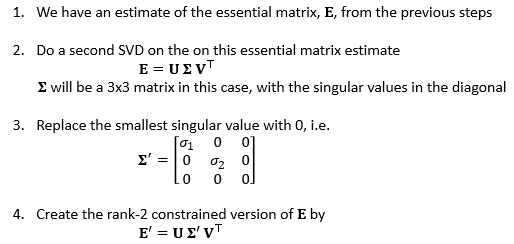
    
Print the rank of the new essential matrix to make sure it worked.

## Enforce rank-2 constraint

In [32]:


############################
# Your code here

#Perform second SVD on essential matrix E 
(Ue,Se,Ve) = np.linalg.svd(E)
Se = np.diag(Se) # Numpy function that reshapes 1D list into 2D list of lists (matrix) 

#Replace the smallest singular value in diagonal of the Se matrix with 0
diag_sv = np.diag(Se) # Extract the diagonal elements
diag_sv_min = np.min(diag_sv)

#Replace the value returned by diag_sv_min with 0 in Se matrix
Se[np.where(diag_sv == diag_sv_min)] = 0
#print(Se)

#Estimate the new essential matrix E_new
E_new = np.dot(Ue, np.dot(Se, Ve))
rankE_new=np.linalg.matrix_rank(E_new)
print(E_new)
print('\n')

#Perform check to confirm that the rank of E_new has been correctly computed as 2
if rankE_new == 2:
    print("The rank of E_new is 2, this is correct")
else:
    print("The rank of E_new is not 2, this is incorrect")

[[ 0.01126381  0.03094609 -0.07535638]
 [ 0.06644953 -0.0100878  -0.70687931]
 [ 0.0901854   0.69340688  0.00344413]]


The rank of E_new is 2, this is correct


Excellent, you have successfully estimated the essential matrix for this image pair!





## Draw some points and epipolar lines

To visualise the essential matrix, there is probably no better way than to draw a set of epipolar lines. So this is what we are going to do. but it's worth having a little discussion first about how to go about this.

Recall that if we have a point in the left image $\mathbf{x}$, we get the parameters of the line, i.e. $l' = \mathbf{Ex}$. $l'$ is represented by a 3-vector, i.e. $l' = (s, t, u)^\top$. However, these parameters are in the normalised image coordinates, and we need to convert to the pixel coordinates. How to do this?
 
Let's call $\mathbf{x}_{img} \leftrightarrow \mathbf{x'}_{img}$ our pixel coordinate, and $\mathbf{x} \leftrightarrow \mathbf{x'}$ the corresponding ideal coordinate, for a given match.

We note that the epipolar constraint is $\mathbf{x'}^\top\mathbf{Ex} = 0$, and that the epipolar line in the right image is $l' = \mathbf{Ex}$. Thus we get the constraint $\mathbf{x'}^\top l' = 0$, by simple substution. This describes that the point $\mathbf{x'}$ lies on the epipolar line $l'$. This is all in normalised image coordinates.

Recall, to move a point from normalised image coordinates to pixel image coordinates, we multiply by the camera intrinsics matrix $\mathbf{K}$, i.e., $\mathbf{x}_{img} = \mathbf{Kx}$, or, conversely, $\mathbf{x} = \mathbf{K}^{-1}\mathbf{x}_{img}$. Then we get the relation, $(\mathbf{K}^{-1}\mathbf{x'}_{img})^\top l' = 0$. By the property of the distribution of transposes, we get $\mathbf{x'}_{img}^\top \mathbf{K}^{-\top} l' = 0$.

This is still a point-line relation. We can say that the normalised point $\mathbf{x'}_{img}^\top \mathbf{K}^{-\top}$ lies on the normalised homogeneous line $l'$, or we can say the image point $\mathbf{x'}_{img}$ lies on the image line $\mathbf{K}^{-\top} l'$.

All of this is a long way of showing that the image (pixel) line coordinates is $l'_{img} = \mathbf{K}^{-\top} l'$, and the relationship $ \mathbf{x'}_{img}^{\top} l'_{img} = 0$.

The elements of the line are $l'_{img} = (s'_{img}, t'_{img}, u'_{img})$. Thus, we get $s'_{img}x'_{img} + t'_{img}y'_{img} + v'_{img} = 0$.
 
 


<font color='blue'>
    
**Task:** Pick a handful of the features, draw the features (in both images), and draw the corresponding epipolar lines in the right hand image. Plot the resulting image pair.
    
Notes:
* To get the epipolar line in the right normalised image, multiply the left ideal/normalised point by the essential matrix $l' = \mathbf{Ex}$
* To get the line in pixel coordinates, do $l'_{img} = \mathbf{K}^{-\top} l'$
* To draw the features (in the left and right images), use [`cv2.circle`](https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html#gaf10604b069374903dbd0f0488cb43670)
* Use the opencv function [`cv2.line`](https://docs.opencv.org/4.x/d6/d6e/group__imgproc__draw.html#ga7078a9fae8c7e7d13d24dac2520ae4a2) to draw the epipolar line
* To draw the line, you need two points on the line, but we have a homogeneous equation $s'_{img}x'_{img} + t'_{img}y'_{img} + v'_{img} = 0$. Get one point by, for example, setting $x'_{img}$ to zero and solving for $y'_{img}$. Similarly, you can set $x'_{img}$ to the image width and solve for $y'_{img}$ again. This will give you two points for the line.
    
No need to do this for all the points - the drawing would be a mess. Just do it for a handfull of points.

## Select feature correspondences

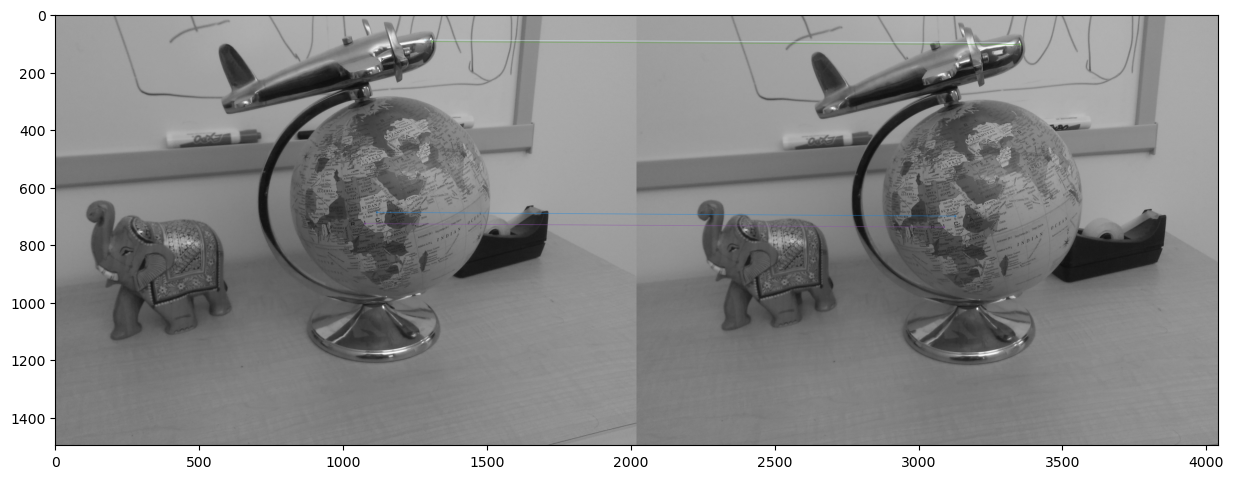

In [61]:
############################
# Your code here



# Pick 4 correspondences between left_pts and rght_pts and match the features between the frames
N_PTS = 4
img4 = cv2.drawMatches(imgL,kp1,imgR,kp2,matches[:N_PTS],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

# Create a clean side-by-side canvas WITHOUT match connection lines
imgL_rgb = cv2.cvtColor(imgL, cv2.COLOR_GRAY2RGB)
imgR_rgb = cv2.cvtColor(imgR, cv2.COLOR_GRAY2RGB)
img4 = np.hstack([imgL_rgb, imgR_rgb])

# Pick 4 correspondences between left_pts and rght_pts and match the features between the frames
img4 = cv2.drawMatches(imgL,kp1,imgR,kp2,matches[:N_PTS],None,flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
plt.figure(figsize = (15,15)),plt.imshow(img4),plt.show();

left_pts = np.float32([kp1[m.queryIdx].pt for m in matches[:N_PTS]]).reshape(-1,2)
rght_pts = np.float32([kp2[m.trainIdx].pt for m in matches[:N_PTS]]).reshape(-1,2)

## Draw circles around feature correspondences

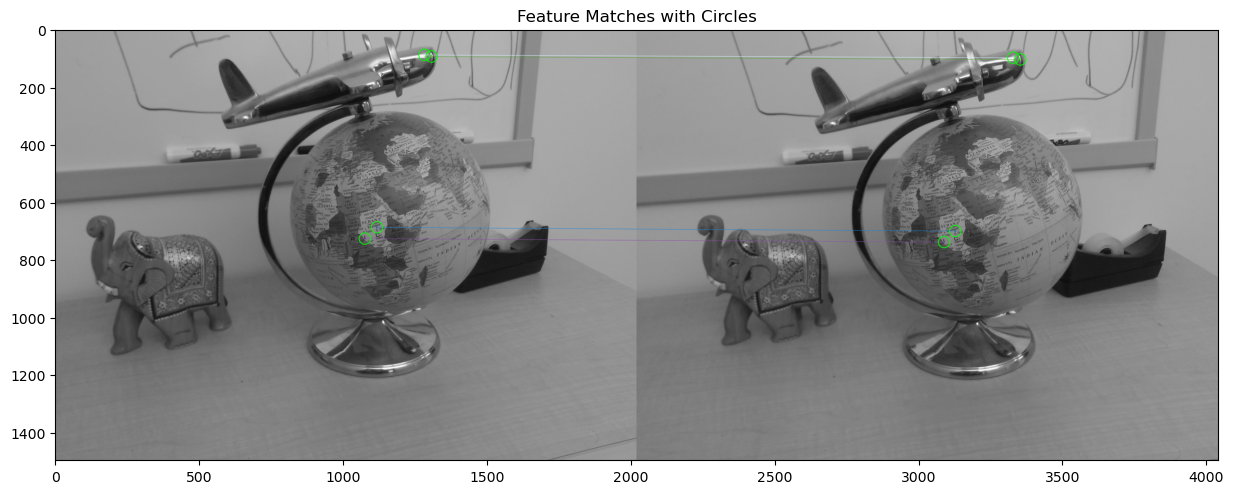

In [62]:
#Select the features in the left and right images and draw a small circle around them
#imgL_rgb = cv2.cvtColor(imgL, cv2.COLOR_GRAY2RGB)
#imgR_rgb = cv2.cvtColor(imgR, cv2.COLOR_GRAY2RGB)
#img_circle = np.hstack([imgL_rgb, imgR_rgb])
img_circle = img4.copy() # Make a copy to draw on, so original img4 is preserved 

# Get the width of the left image for offsetting right image points
imgL_width = imgL.shape[1]

# Define circle parameters
radius = 20
color = (0, 255, 0) # Green color in BGR for OpenCV, but matplotlib expects RGB, so it will appear green.
thickness = 2

# Draw circles on left image points
for pt in left_pts:
    center = (int(pt[0]), int(pt[1]))
    cv2.circle(img_circle, center, radius, color, thickness)

# Draw circles on right image points (adjusting x-coordinate)
for pt in rght_pts:
    center = (int(pt[0] + imgL_width), int(pt[1]))
    cv2.circle(img_circle, center, radius, color, thickness)

# Display the image with circles
plt.figure(figsize = (15,15))
plt.imshow(img_circle)
plt.title('Feature Matches with Circles')
plt.show()

## Homogenise and normalise features

In [63]:

#Convert left points and right points to homogenous co-ordinates
left_pts_hom = np.append(left_pts, np.ones((left_pts.shape[0], 1)), axis=1)
rght_pts_hom = np.append(rght_pts, np.ones((rght_pts.shape[0], 1)), axis=1)

#Initialise lists for left_pts_dist and rght_pts_dist
left_pts_dist = np.zeros((left_pts_hom.shape[0], 3))
rght_pts_dist = np.zeros((rght_pts_hom.shape[0], 3))

#Apply normalisation to obtain the left ideal/normalised points. Multipy left points by K_inv
for i in range(left_pts_hom.shape[0]):
    left_pts_dist[i] = np.dot(K_inv, left_pts_hom[i])
    rght_pts_dist[i] = np.dot(K_inv, rght_pts_hom[i])

print(left_pts_hom)
print('\n')
print(left_pts_dist)
#print(left_pts_hom.shape[0])
#print(left_pts_dist.shape[0])

[[1.11800000e+03 6.88000000e+02 1.00000000e+00]
 [1.07640002e+03 7.27200012e+02 1.00000000e+00]
 [1.30844177e+03 9.53856125e+01 1.00000000e+00]
 [1.28397339e+03 8.95795441e+01 1.00000000e+00]]


[[ 0.03376381 -0.04824937  1.        ]
 [ 0.01193655 -0.02758808  1.        ]
 [ 0.13368747 -0.36060076  1.        ]
 [ 0.12084906 -0.36366099  1.        ]]


## Get epipolar line and get line in pixel coordinates

In [64]:
# Initialize a list to store all epipolar lines in pixel coordinates
epipolar_lines_img = []

# Loop through each normalized left point
for i in range(left_pts_dist.shape[0]):
    # Get the epipolar line in the right normalized image,multiply by essential matrix as given in notes above
    l_ = np.dot(E_new, left_pts_dist[i])

    # Get the line in pixel coordinates as given in notes above
    l_img = np.dot(K_inv.T, l_)

    # Append to the list
    epipolar_lines_img.append(l_img)

print("Calculated epipolar lines (pixel coordinates):")
for line in epipolar_lines_img:
    print(line)

Calculated epipolar lines (pixel coordinates):
[-4.01229334e-05 -3.71138339e-04  3.04626156e-01]
[-3.99164515e-05 -3.72012668e-04  3.17448355e-01]
[-4.46041009e-05 -3.65977856e-04  9.77499762e-02]
[-4.47296662e-05 -3.66411235e-04  9.49402962e-02]


## Function to calculate the points of the epipolar line

In [65]:
#Define function to calculate the points of the epipolar line
def calc_epipolar_line(pixel_coordinates, img_width):
  # Ensure pixel_coordinates is a NumPy array for consistent behavior
  pixel_coordinates = np.asarray(pixel_coordinates)

  # Correct length check
  if pixel_coordinates.shape != (3,):
    print("Error: pixel_coordinates must be a 3-element vector (s_img, t_img, v_img)")
    return None, None # Return None for both points to indicate failure

  s_img = pixel_coordinates[0]
  t_img = pixel_coordinates[1]
  v_img = pixel_coordinates[2]

  # Calculate y-coordinates for x=0 and x=img_width
  x0 = 0
  y0 = (-v_img - s_img * x0) / t_img

  x1 = img_width
  y1 = (-v_img - s_img * x1) / t_img

  # Return integer pixel coordinates
  pt0 = (int(x0), int(y0))
  pt1 = (int(x1), int(y1))

  return pt0, pt1

## Calculate Epipolar Line points

In [66]:
epi_points=[]
for line in epipolar_lines_img:
    points = calc_epipolar_line(line, imgR.shape[1])
    epi_points.append(points)
print(epi_points)

[((0, 820), (2020, 602)), ((0, 853), (2020, 636)), ((0, 267), (2020, 20)), ((0, 259), (2020, 12))]


## Draw epipolar line on image

(2020, 820) (4040, 602)
(2020, 853) (4040, 636)
(2020, 267) (4040, 20)
(2020, 259) (4040, 12)


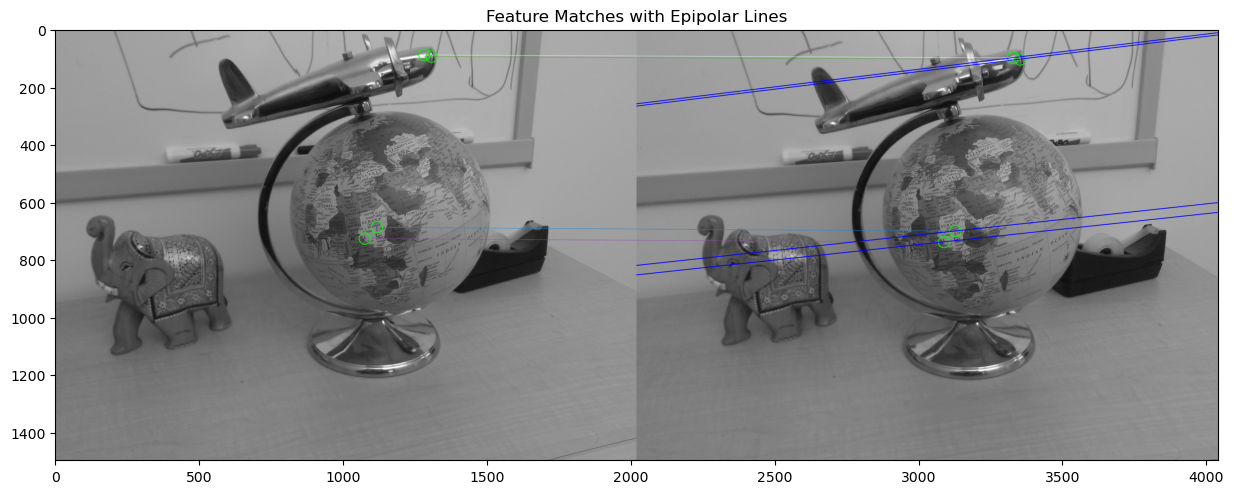

In [69]:
img = img_circle.copy() # Use the image with circles drawn on it
# Draw a blue line (BGR: 255, 0, 0)
imgL_width = imgL.shape[1]
for points in epi_points:
    pt0 = (points[0][0] + imgL_width, points[0][1])
    pt1 = (points[1][0] + imgL_width, points[1][1])
    cv2.line(img, pt0, pt1, (0, 0, 255), 2)
    print(pt0, pt1)
# Display the image with epipolar line using matplotlib
plt.figure(figsize = (15,15))
plt.imshow(img)
plt.title('Feature Matches with Epipolar Lines')
plt.show()

**Commentary**: when I implemented this, it worked OK, but definitely wasn't perfect. My epipolar lines didn't always intersect with their corresponding features, again due to the DLT not being robust. We're going to move on and do a robust homography estimation. But, lucky for you, we'll use OpenCV (we probably had enough of implementing our own RANSAC algorithm from the last e-tivity).

<font color='blue'>

# Questions

<font color='blue'>

**Question**: Discuss the importance of the rank(2) constraint on the essential matrix estimation (hint: Lecture 5.14)

! Double click to add text

<font color='blue'>

**Question**: Describe what *you* see when *you* draw the epipolar lines. How does it look?

! Double click to add text

<font color='blue'>
   
**Question**: How would you go about finding the epipolar lines in left image?

! Double click to add text

<font color='blue'>

**Question**: You may need a bit of a web search to answer this one. In both the homography estimation and the essential matrix estimation, we took the result column of $\mathbf{V}$ that corresponded to the smallest singular value to be our estimate (i.e., the right most column). But why the smallest singular value?

! Double click to add text